# VARX Model with Emotion Indices: Lags and Leads

This notebook trains **VARX (Vector AutoRegressive with eXogenous variables)** models enhanced with emotion indices. Unlike the univariate ARX models, VARX captures **cross-asset spillovers** and dynamic interactions between BTC, Gold, and SPX.

## Key Concept: Lags vs Leads

- **Lags (q)**: Past values predicting future returns
  - `soc_ei_lag1` = emotion index 1 day ago → predicts return tomorrow
  - Traditional approach: X(t-k) → Y(t+1)

- **Leads (f)**: Future values (available before prediction target) predicting returns
  - `soc_ei_lead1` = emotion index 1 day ahead → predicts return tomorrow
  - Exploits timing: if index updates faster than returns, X(t+k) → Y(t+1)

The optimization searches over **both lags and leads** (ranges 0-3) to discover optimal temporal relationships for each emotion family. This allows the model to identify whether past sentiment, concurrent sentiment, or near-future sentiment best predicts asset returns.

**Important**: Leads are only applied to emotion indices, not to control variables or lagged returns, as we assume emotion indices may update faster than market prices.

In [7]:
# Configuration
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path

plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 6)})
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = DATA_DIR / 'fm_prelim'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling
Output directory: /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim


In [8]:
# Import custom modules
from modules.finance.models.varx import (
    VARXLagSpec,
    automl_varx_optuna,
    make_varx_design_heterogeneous
)
from modules.finance.models.arx import INDEX_FAMILIES, _classify_social_columns
from modules.finance.evaluation.metrics import (
    compute_all_metrics,
    bootstrap_coefficient_ci,
    diebold_mariano_test,
    clark_west_test,
    permutation_importance_cv,
    apply_fdr_correction,
    get_significance_stars
)
from modules.finance.visualisation.feature_importance import (
    plot_coefficient_importance,
    plot_shap_summary,
    plot_permutation_importance,
    plot_model_comparison_bars,
    plot_family_importance_summary
)

print("Modules imported successfully")

Modules imported successfully


## Load Data

In [9]:
# Load financial data
df = pd.read_csv(DATA_DIR / 'financial_returns_and_controls.csv', index_col=0, parse_dates=True)
df = df.sort_index()

# Load emotion data from epi_data.json
import json
with open(DATA_DIR / 'epi_data.json', 'r') as f:
    epi_data = json.load(f)

epi_df = pd.DataFrame(epi_data)
epi_df['date'] = pd.to_datetime(epi_df['date'])
epi_df = epi_df.set_index('date').sort_index()

print(f"Financial data shape: {df.shape}")
print(f"Emotion data shape: {epi_df.shape}")

# Join emotion data with financial data
df = df.join(epi_df, how='left')
print(f"Joined data shape: {df.shape}")

TARGET_COLS = ['r_btc', 'r_gold', 'r_spx', 'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 'r_aapl']
CONTROL_COLS = ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']

# Forward fill controls
for col in CONTROL_COLS:
    if col in df.columns:
        df[col] = df[col].ffill()

# Identify emotion index columns (all columns from epi_df)
emotion_cols = [col for col in epi_df.columns if col not in ['date']]

# Prepare clean data
df_clean = df.dropna(subset=TARGET_COLS)
for col in emotion_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

print(f"\nClean data shape: {df_clean.shape}")
print(f"Date range: {df_clean.index.min()} to {df_clean.index.max()}")
print(f"Target columns: {TARGET_COLS}")
print(f"Control columns: {CONTROL_COLS}")
print(f"Emotion columns: {len(emotion_cols)}")

Financial data shape: (104, 44)
Emotion data shape: (148, 27)
Joined data shape: (104, 71)

Clean data shape: (104, 71)
Date range: 2025-01-07 00:00:00 to 2025-05-30 00:00:00
Target columns: ['r_btc', 'r_gold', 'r_spx', 'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 'r_aapl']
Control columns: ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']
Emotion columns: 27


## Emotion-Enhanced VARX Configuration

### Economic Interpretation of Lag/Lead Patterns

The optimization may discover three types of temporal patterns:

1. **Lag-only (q > 0, f = 0)**: Past emotion predicts returns
   - Interpretation: Markets react with delay to sentiment shifts
   - Example: Yesterday's fear → today's selling

2. **Lead-only (q = 0, f > 0)**: Future emotion predicts returns
   - Interpretation: Emotion indices update faster than prices
   - Example: Today's optimism signal → tomorrow's rally (if signal available before market close)

3. **Mixed (q > 0, f > 0)**: Both past and future emotion matter
   - Interpretation: Persistent sentiment + timing advantage
   - Example: Sustained bearishness + fresh signals

The model will automatically select the combination that minimizes out-of-sample prediction error.

In [10]:
# Configuration
EMOTION_CONFIG = {
    'p_range': (1, 5),
    'q_control_range': (0, 3),
    'q_ei_range': (0, 3),
    'q_epi_range': (0, 3),
    'q_epi_signed_range': (0, 3),
    'q_ccd_range': (0, 3),
    'q_intensity_range': (0, 3),
    'q_surprise_range': (0, 3),
    'q_split_range': (0, 3),
    'f_ei_range': (0, 3),
    'f_epi_range': (0, 3),
    'f_epi_signed_range': (0, 3),
    'f_ccd_range': (0, 3),
    'f_intensity_range': (0, 3),
    'f_surprise_range': (0, 3),
    'f_split_range': (0, 3),
    'n_trials': 5000,
    'cv_initial': 60,
    'cv_step': 1,
    'cv_test': 1,
}

print("VARX Emotion Configuration:")
for k, v in EMOTION_CONFIG.items():
    print(f"  {k}: {v}")

VARX Emotion Configuration:
  p_range: (1, 5)
  q_control_range: (0, 3)
  q_ei_range: (0, 3)
  q_epi_range: (0, 3)
  q_epi_signed_range: (0, 3)
  q_ccd_range: (0, 3)
  q_intensity_range: (0, 3)
  q_surprise_range: (0, 3)
  q_split_range: (0, 3)
  f_ei_range: (0, 3)
  f_epi_range: (0, 3)
  f_epi_signed_range: (0, 3)
  f_ccd_range: (0, 3)
  f_intensity_range: (0, 3)
  f_surprise_range: (0, 3)
  f_split_range: (0, 3)
  n_trials: 5000
  cv_initial: 60
  cv_step: 1
  cv_test: 1


## Train Emotion-Enhanced VARX Model

In [11]:
# Prepare data matrices
Y_endog = df_clean[TARGET_COLS].values
X_controls = df_clean[CONTROL_COLS].fillna(0).values
X_emotion = df_clean[emotion_cols].values if emotion_cols else None

# Combine controls and emotion for exogenous
if X_emotion is not None:
    X_exog = np.hstack([X_controls, X_emotion])
    exog_names = CONTROL_COLS + emotion_cols
else:
    X_exog = X_controls
    exog_names = CONTROL_COLS

print(f"Endogenous shape: {Y_endog.shape}")
print(f"Exogenous shape: {X_exog.shape}")

Endogenous shape: (104, 8)
Exogenous shape: (104, 31)


In [12]:
# Train VARX with emotion indices
print("Training emotion-enhanced VARX model...")
print("="*60)

# Prepare DataFrames
Y_df = df_clean[TARGET_COLS]
X_df = df_clean[CONTROL_COLS + emotion_cols].fillna(0)

varx_result = automl_varx_optuna(
    Y=Y_df,
    X=X_df,
    p_range=EMOTION_CONFIG['p_range'],
    q_controls_range=EMOTION_CONFIG['q_control_range'],
    q_ei_range=EMOTION_CONFIG['q_ei_range'],
    q_epi_range=EMOTION_CONFIG['q_epi_range'],
    q_epi_signed_range=EMOTION_CONFIG['q_epi_signed_range'],
    q_ccd_range=EMOTION_CONFIG['q_ccd_range'],
    q_intensity_range=EMOTION_CONFIG['q_intensity_range'],
    q_surprise_range=EMOTION_CONFIG['q_surprise_range'],
    q_split_range=EMOTION_CONFIG['q_split_range'],
    f_ei_range=EMOTION_CONFIG['f_ei_range'],
    f_epi_range=EMOTION_CONFIG['f_epi_range'],
    f_epi_signed_range=EMOTION_CONFIG['f_epi_signed_range'],
    f_ccd_range=EMOTION_CONFIG['f_ccd_range'],
    f_intensity_range=EMOTION_CONFIG['f_intensity_range'],
    f_surprise_range=EMOTION_CONFIG['f_surprise_range'],
    f_split_range=EMOTION_CONFIG['f_split_range'],
    n_trials=EMOTION_CONFIG['n_trials'],
    initial_train=EMOTION_CONFIG['cv_initial'],
    step=EMOTION_CONFIG['cv_step'],
    val_size=EMOTION_CONFIG['cv_test'],
)

best_spec = varx_result['best_lags']

print(f"\nBest VARX specification:")
print(f"  Endogenous lags (p): {best_spec.p}")
print(f"  Control lags: {best_spec.q_controls}")
print(f"  EI lags: {best_spec.q_ei}, leads: {best_spec.f_ei}")
print(f"  EPI lags: {best_spec.q_epi}, leads: {best_spec.f_epi}")
print(f"  EPI_Signed lags: {best_spec.q_epi_signed}, leads: {best_spec.f_epi_signed}")
print(f"  CCD lags: {best_spec.q_ccd}, leads: {best_spec.f_ccd}")
print(f"  Intensity lags: {best_spec.q_intensity}, leads: {best_spec.f_intensity}")
print(f"  Surprise lags: {best_spec.q_surprise}, leads: {best_spec.f_surprise}")
print(f"  Split lags: {best_spec.q_split}, leads: {best_spec.f_split}")
print(f"\nCV MAE: {varx_result['best_score_mae']:.6f}")
print(f"CV RMSE: {varx_result['best_score_rmse']:.6f}")

Training emotion-enhanced VARX model...


Optuna VARX Optimization: 100%|██████████| 5000/5000 [43:17<00:00,  1.93it/s, best_mae=0.0146, trials_since_improvement=450]   


Best VARX specification:
  Endogenous lags (p): 2
  Control lags: 1
  EI lags: 2, leads: 0
  EPI lags: 3, leads: 0
  EPI_Signed lags: 3, leads: 1
  CCD lags: 3, leads: 0
  Intensity lags: 2, leads: 0
  Surprise lags: 2, leads: 0
  Split lags: 3, leads: 0

CV MAE: 0.014583
CV RMSE: 0.017250


## Out-of-Sample Evaluation

In [13]:
# Get design matrices from result (already computed during optimization)
Z_design = varx_result['Z_design']
Y_target = varx_result['Y_target']
feature_names = varx_result['feature_names']

print(f"Design matrix shape: {Z_design.shape}")
print(f"Target matrix shape: {Y_target.shape}")
print(f"Features: {len(feature_names)}")

Design matrix shape: (101, 118)
Target matrix shape: (101, 8)
Features: 118


In [14]:
# Generate OOS predictions
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, MultiTaskElasticNet

oos_predictions = {target: {'y_true': [], 'y_pred': [], 'dates': []} for target in TARGET_COLS}

initial_train = EMOTION_CONFIG['cv_initial']
step_size = EMOTION_CONFIG['cv_step']
test_size = EMOTION_CONFIG['cv_test']
n_samples = len(Y_target)

best_params = varx_result['best_model_params']
model_family = varx_result['best_model_family']

print("Generating OOS predictions...")

for train_end in range(initial_train, n_samples - test_size + 1, step_size):
    test_start = train_end
    test_end = test_start + test_size
    
    Z_train = Z_design.iloc[:train_end]
    Z_test = Z_design.iloc[test_start:test_end]
    Y_train = Y_target.iloc[:train_end]
    Y_test = Y_target.iloc[test_start:test_end]
    
    # Build model
    if model_family == "ridge":
        model = Ridge(**best_params)
    else:
        model = MultiTaskElasticNet(**best_params, max_iter=20000)
    
    pipe = Pipeline([("scaler", StandardScaler()), ("reg", model)])
    pipe.fit(Z_train, Y_train)
    Y_pred = pipe.predict(Z_test)
    
    for i, target in enumerate(TARGET_COLS):
        oos_predictions[target]['y_true'].extend(Y_test.iloc[:, i].values)
        oos_predictions[target]['y_pred'].extend(Y_pred[:, i])
        oos_predictions[target]['dates'].extend(Y_test.index.tolist())

# Compute metrics
oos_metrics = {}
for target in TARGET_COLS:
    oos_predictions[target] = pd.DataFrame({
        'date': oos_predictions[target]['dates'],
        'y_true': oos_predictions[target]['y_true'],
        'y_pred': oos_predictions[target]['y_pred']
    }).set_index('date')
    
    oos_metrics[target] = compute_all_metrics(
        np.array(oos_predictions[target]['y_true']),
        np.array(oos_predictions[target]['y_pred'])
    )

print("Done!")

Generating OOS predictions...
Done!


In [15]:
# Display metrics
print("\n" + "="*60)
print("OUT-OF-SAMPLE METRICS (VARX + Emotion)")
print("="*60)

metrics_data = []
for target, metrics in oos_metrics.items():
    metrics_data.append({
        'Asset': target,
        'MAE': metrics['mae'],
        'RMSE': metrics['rmse'],
        'R²': metrics['r2'],
    })

display(pd.DataFrame(metrics_data).style.format({
}))


OUT-OF-SAMPLE METRICS (VARX + Emotion)


,Asset,MAE,RMSE,R²
0,r_btc,0.015412,0.019498,-0.001201
1,r_gold,0.009674,0.012370,-0.335612
2,r_spx,0.010704,0.017866,-0.062677
3,r_spx_auto,0.023789,0.035966,-0.076991
4,r_spx_oilgas,0.011563,0.018510,0.027928
5,r_spx_mach,0.010876,0.017452,-0.073041
6,r_spx_elec,0.014149,0.020589,-0.067685
7,r_aapl,0.017054,0.027162,-0.053634


## Compare with Baseline VARX

Use Clark-West test for nested model comparison (baseline is nested within emotion model).

In [16]:
# Load baseline VARX results
baseline_path = OUTPUT_DIR / 'varx_baseline_metrics.csv'

if baseline_path.exists():
    baseline_df = pd.read_csv(baseline_path)
    
    print("Model Comparison: Baseline vs Emotion VARX")
    print("="*70)
    
    comparison_data = []
    cw_results = {}
    
    for target in TARGET_COLS:
        baseline_row = baseline_df[baseline_df['asset'] == target].iloc[0]
        emotion_metrics = oos_metrics[target]
        
        # Load predictions for Clark-West test
        baseline_pred_path = OUTPUT_DIR / f'varx_baseline_predictions_{target}.csv'
        if baseline_pred_path.exists():
            baseline_preds = pd.read_csv(baseline_pred_path, index_col='date', parse_dates=True)
            emotion_preds = oos_predictions[target]
            
            common_dates = baseline_preds.index.intersection(emotion_preds.index)
            baseline_aligned = baseline_preds.loc[common_dates]
            emotion_aligned = emotion_preds.loc[common_dates]
            
            # Clark-West test (baseline is restricted model)
            cw_result = clark_west_test(
                baseline_aligned['y_true'].values,
                baseline_aligned['y_pred'].values,
                emotion_aligned['y_pred'].values
            )
            cw_results[target] = {'statistic': cw_result['statistic'], 'p_value': cw_result['pvalue']}
        else:
            cw_results[target] = {'statistic': None, 'p_value': None}
        
        mae_improvement = (baseline_row['oos_mae'] - emotion_metrics['mae']) / baseline_row['oos_mae'] * 100
        
        comparison_data.append({
            'Asset': target,
            'Baseline MAE': baseline_row['oos_mae'],
            'Emotion MAE': emotion_metrics['mae'],
            'Improvement (%)': mae_improvement,
            'Clark-West p-value': cw_results[target]['p_value'],
            'Significance': get_significance_stars(cw_results[target]['p_value']) if cw_results[target]['p_value'] else ''
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df.style.format({
        'Baseline MAE': '{:.6f}', 'Emotion MAE': '{:.6f}', 
        'Improvement (%)': '{:+.2f}', 'Clark-West p-value': '{:.4f}'
    }))
    
    print("\nNote: Positive improvement indicates emotion model is better.")
    print("Clark-West test: H0 = baseline forecasts as well as emotion model.")
else:
    print("Baseline VARX results not found. Run 411_fm_baseline_varx.ipynb first.")

Model Comparison: Baseline vs Emotion VARX


,Asset,Baseline MAE,Emotion MAE,Improvement (%),Clark-West p-value,Significance
0,r_btc,0.015308,0.015412,-0.68,0.6658,
1,r_gold,0.009477,0.009674,-2.09,0.1426,
2,r_spx,0.011237,0.010704,+4.74,0.3155,
3,r_spx_auto,0.023422,0.023789,-1.57,0.7692,
4,r_spx_oilgas,0.012571,0.011563,+8.02,0.7148,
5,r_spx_mach,0.011935,0.010876,+8.87,0.4914,
6,r_spx_elec,0.015377,0.014149,+7.98,0.4691,
7,r_aapl,0.018536,0.017054,+8.00,0.2443,



Note: Positive improvement indicates emotion model is better.
Clark-West test: H0 = baseline forecasts as well as emotion model.


## Feature Importance Analysis

In [17]:
# Bootstrap coefficient analysis
print("="*60)
print("COEFFICIENT ANALYSIS WITH BOOTSTRAP CIs")
print("="*60)

# For VARX, we analyze per-target using the shared design matrix
bootstrap_results = {}

# Get model parameters from result
best_params = varx_result['best_model_params']
model_family = varx_result['best_model_family']

for target in TARGET_COLS:
    print(f"\nBootstrap analysis for {target}...")
    
    target_idx = TARGET_COLS.index(target)
    y_target_arr = Y_target.iloc[:, target_idx].values
    
    # Build a single-target pipeline for bootstrap
    from sklearn.linear_model import Ridge, ElasticNet
    if model_family == "ridge":
        model = Ridge(alpha=best_params.get('alpha', 1.0))
    else:
        model = ElasticNet(
            alpha=best_params.get('alpha', 1.0),
            l1_ratio=best_params.get('l1_ratio', 0.5),
            max_iter=20000
        )
    
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    pipe.fit(Z_design.values, y_target_arr)
    
    ci_results = bootstrap_coefficient_ci(
        Z_design.values, y_target_arr,
        pipeline=pipe,
        feature_names=feature_names,
        n_iter=1000,
        alpha_levels=[0.01, 0.05, 0.10]
    )
    
    bootstrap_results[target] = ci_results
    
    sig_05 = ci_results['sig_95'].sum()
    print(f"  Significant features (5%): {sig_05}")

COEFFICIENT ANALYSIS WITH BOOTSTRAP CIs

Bootstrap analysis for r_btc...
  Significant features (5%): 0

Bootstrap analysis for r_gold...
  Significant features (5%): 0

Bootstrap analysis for r_spx...
  Significant features (5%): 0

Bootstrap analysis for r_spx_auto...
  Significant features (5%): 0

Bootstrap analysis for r_spx_oilgas...
  Significant features (5%): 0

Bootstrap analysis for r_spx_mach...
  Significant features (5%): 0

Bootstrap analysis for r_spx_elec...
  Significant features (5%): 0

Bootstrap analysis for r_aapl...
  Significant features (5%): 0


In [18]:
# SHAP Analysis
print("\n" + "="*60)
print("SHAP ANALYSIS")
print("="*60)

shap_results = {}
fitted_pipeline = varx_result['fitted_pipeline']
scaler = fitted_pipeline.named_steps['scaler']
Z_scaled = scaler.transform(Z_design.values)

for target in TARGET_COLS:
    print(f"\nComputing SHAP values for {target}...")
    target_idx = TARGET_COLS.index(target)
    
    if model_family == "ridge":
        model = Ridge(alpha=best_params.get('alpha', 1.0))
    else:
        model = ElasticNet(alpha=best_params.get('alpha', 1.0), 
                          l1_ratio=best_params.get('l1_ratio', 0.5), 
                          max_iter=20000)
    
    y_target_arr = Y_target.iloc[:, target_idx].values
    model.fit(Z_scaled, y_target_arr)
    
    explainer = shap.LinearExplainer(model, Z_scaled)
    shap_values = explainer.shap_values(Z_scaled)
    mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
    
    shap_results[target] = {
        'shap_values': shap_values,
        'X_design': Z_scaled,
        'feature_names': feature_names,
        'mean_abs_shap': dict(zip(feature_names, mean_abs_shap))
    }
    
    sorted_shap = sorted(zip(feature_names, mean_abs_shap), 
                        key=lambda x: x[1], reverse=True)
    print(f"  Top 5 features:")
    for feat, val in sorted_shap[:5]:
        print(f"    {feat}: {val:.6f}")


SHAP ANALYSIS

Computing SHAP values for r_btc...
  Top 5 features:
    r_btc_lag1: 0.000000
    r_gold_lag1: 0.000000
    r_spx_lag1: 0.000000
    r_spx_auto_lag1: 0.000000
    r_spx_oilgas_lag1: 0.000000

Computing SHAP values for r_gold...
  Top 5 features:
    r_btc_lag1: 0.000000
    r_gold_lag1: 0.000000
    r_spx_lag1: 0.000000
    r_spx_auto_lag1: 0.000000
    r_spx_oilgas_lag1: 0.000000

Computing SHAP values for r_spx...
  Top 5 features:
    r_btc_lag1: 0.000000
    r_gold_lag1: 0.000000
    r_spx_lag1: 0.000000
    r_spx_auto_lag1: 0.000000
    r_spx_oilgas_lag1: 0.000000

Computing SHAP values for r_spx_auto...
  Top 5 features:
    r_btc_lag1: 0.000000
    r_gold_lag1: 0.000000
    r_spx_lag1: 0.000000
    r_spx_auto_lag1: 0.000000
    r_spx_oilgas_lag1: 0.000000

Computing SHAP values for r_spx_oilgas...
  Top 5 features:
    r_btc_lag1: 0.000000
    r_gold_lag1: 0.000000
    r_spx_lag1: 0.000000
    r_spx_auto_lag1: 0.000000
    r_spx_oilgas_lag1: 0.000000

Computing S

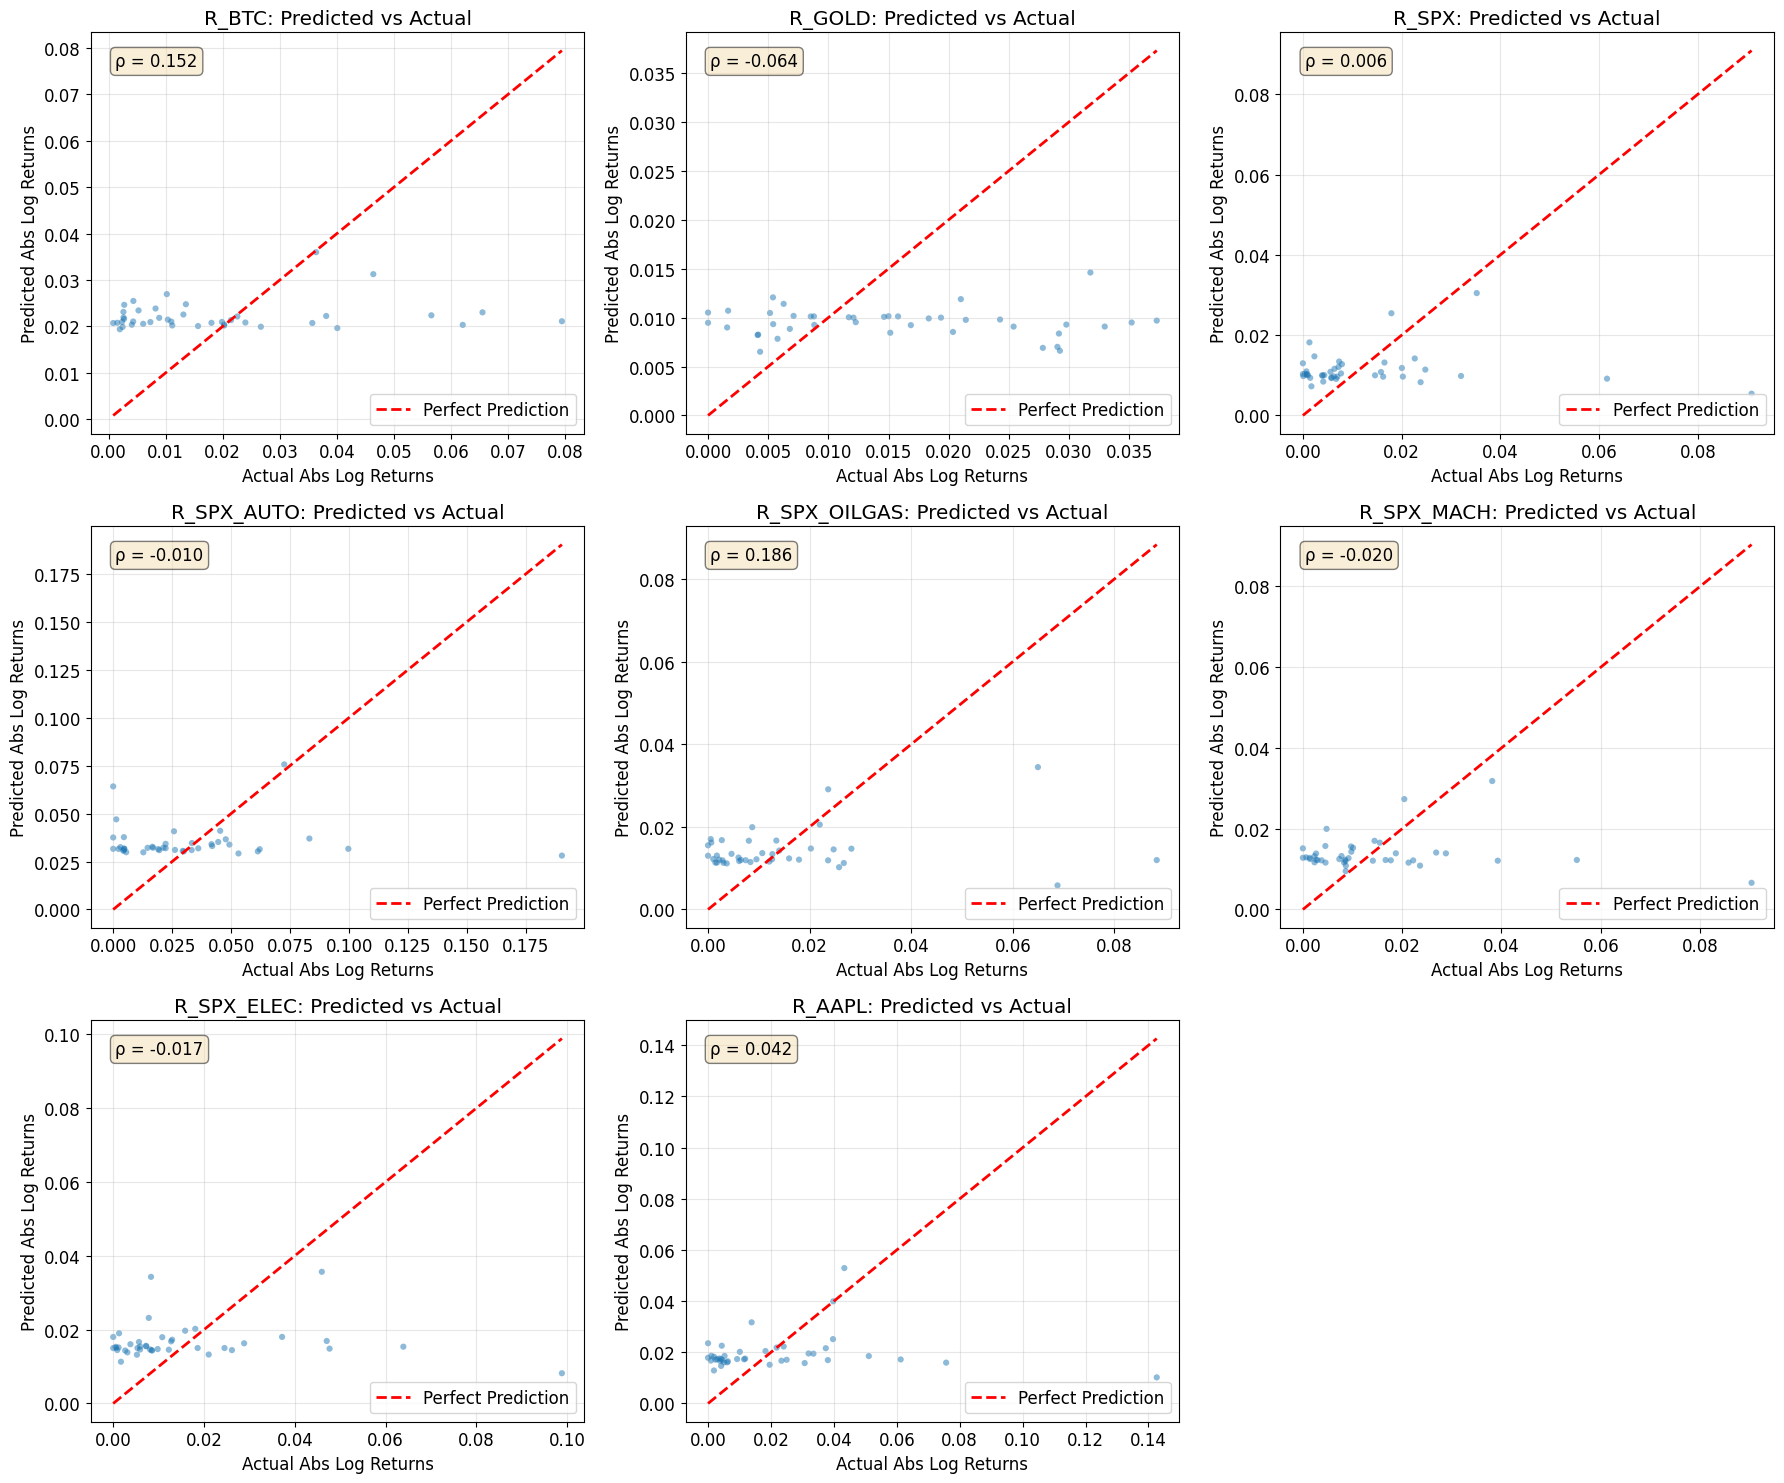


Correlation between predicted and actual:
  r_btc: 0.1520
  r_gold: -0.0644
  r_spx: 0.0062
  r_spx_auto: -0.0100
  r_spx_oilgas: 0.1860
  r_spx_mach: -0.0196
  r_spx_elec: -0.0173
  r_aapl: 0.0415


In [19]:
# Plot predicted vs actual absolute log returns
n_cols = min(3, len(TARGET_COLS))
n_rows = (len(TARGET_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    preds_df = oos_predictions[target]
    
    # Scatter plot
    ax.scatter(preds_df['y_true'], preds_df['y_pred'], alpha=0.5, s=20, edgecolors='none')
    
    # Perfect prediction line
    min_val = min(preds_df['y_true'].min(), preds_df['y_pred'].min())
    max_val = max(preds_df['y_true'].max(), preds_df['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    # Labels and title
    ax.set_xlabel('Actual Abs Log Returns')
    ax.set_ylabel('Predicted Abs Log Returns')
    ax.set_title(f'{target.upper()}: Predicted vs Actual')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr = np.corrcoef(preds_df['y_true'], preds_df['y_pred'])[0, 1]
    ax.text(0.05, 0.95, f'ρ = {corr:.3f}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide extra subplots if any
for idx in range(len(TARGET_COLS), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'varx_baseline_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation between predicted and actual:")
for target in TARGET_COLS:
    preds_df = oos_predictions[target]
    corr = np.corrcoef(preds_df['y_true'], preds_df['y_pred'])[0, 1]
    print(f"  {target}: {corr:.4f}")

In [20]:
# Top significant emotion features
print("\n" + "="*60)
print("TOP SIGNIFICANT EMOTION FEATURES")
print("="*60)

for target in TARGET_COLS:
    print(f"\n{target}:")
    results_df = bootstrap_results[target]
    
    # Filter emotion features (not in targets or controls)
    emotion_mask = ~results_df.index.str.split('_lag').str[0].isin(TARGET_COLS + CONTROL_COLS)
    sig_mask = results_df['sig_95'] == True
    emotion_features = results_df[emotion_mask & sig_mask]
    
    if len(emotion_features) > 0:
        sorted_features = emotion_features.reindex(
            emotion_features['coef'].abs().sort_values(ascending=False).index
        )
        for feat in sorted_features.index[:10]:
            row = sorted_features.loc[feat]
            print(f"  {feat}: {row['coef']:.6f} {row['stars']}")
    else:
        print("  No significant emotion features.")


TOP SIGNIFICANT EMOTION FEATURES

r_btc:
  No significant emotion features.

r_gold:
  No significant emotion features.

r_spx:
  No significant emotion features.

r_spx_auto:
  No significant emotion features.

r_spx_oilgas:
  No significant emotion features.

r_spx_mach:
  No significant emotion features.

r_spx_elec:
  No significant emotion features.

r_aapl:
  No significant emotion features.


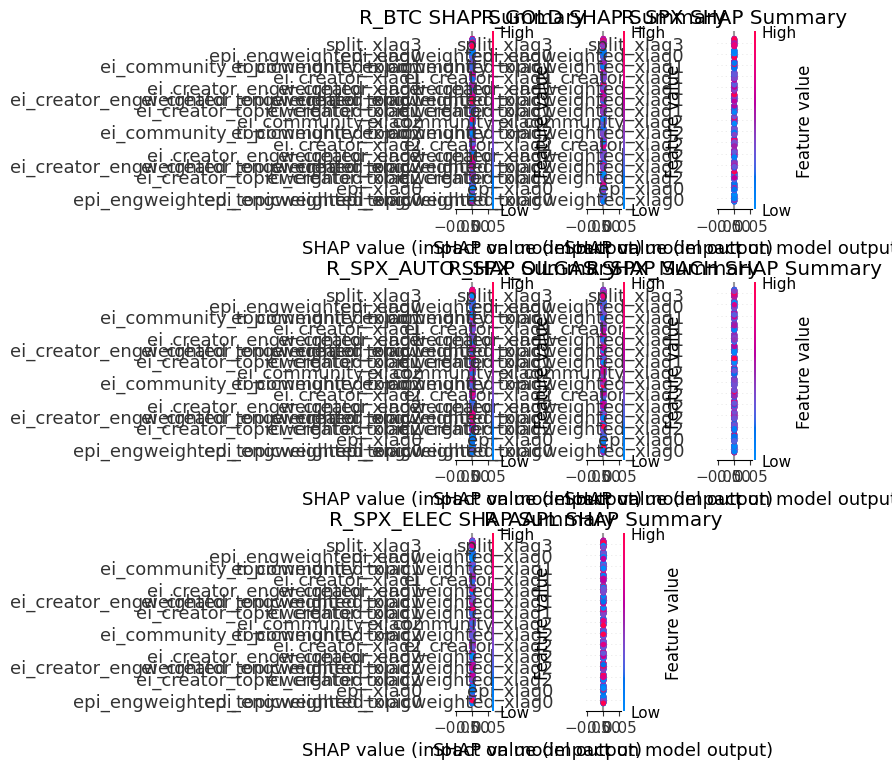

In [21]:
# SHAP Summary Plots
n_cols = min(3, len(TARGET_COLS))
n_rows = (len(TARGET_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 8*n_rows))
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

for idx, target in enumerate(TARGET_COLS):
    plt.sca(axes[idx])
    shap.summary_plot(
        shap_results[target]['shap_values'],
        shap_results[target]['X_design'],
        feature_names=shap_results[target]['feature_names'],
        max_display=15,
        show=False
    )
    axes[idx].set_title(f'{target.upper()} SHAP Summary')

# Hide extra subplots if any
for idx in range(len(TARGET_COLS), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'varx_emotion_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Cumulative Returns Analysis

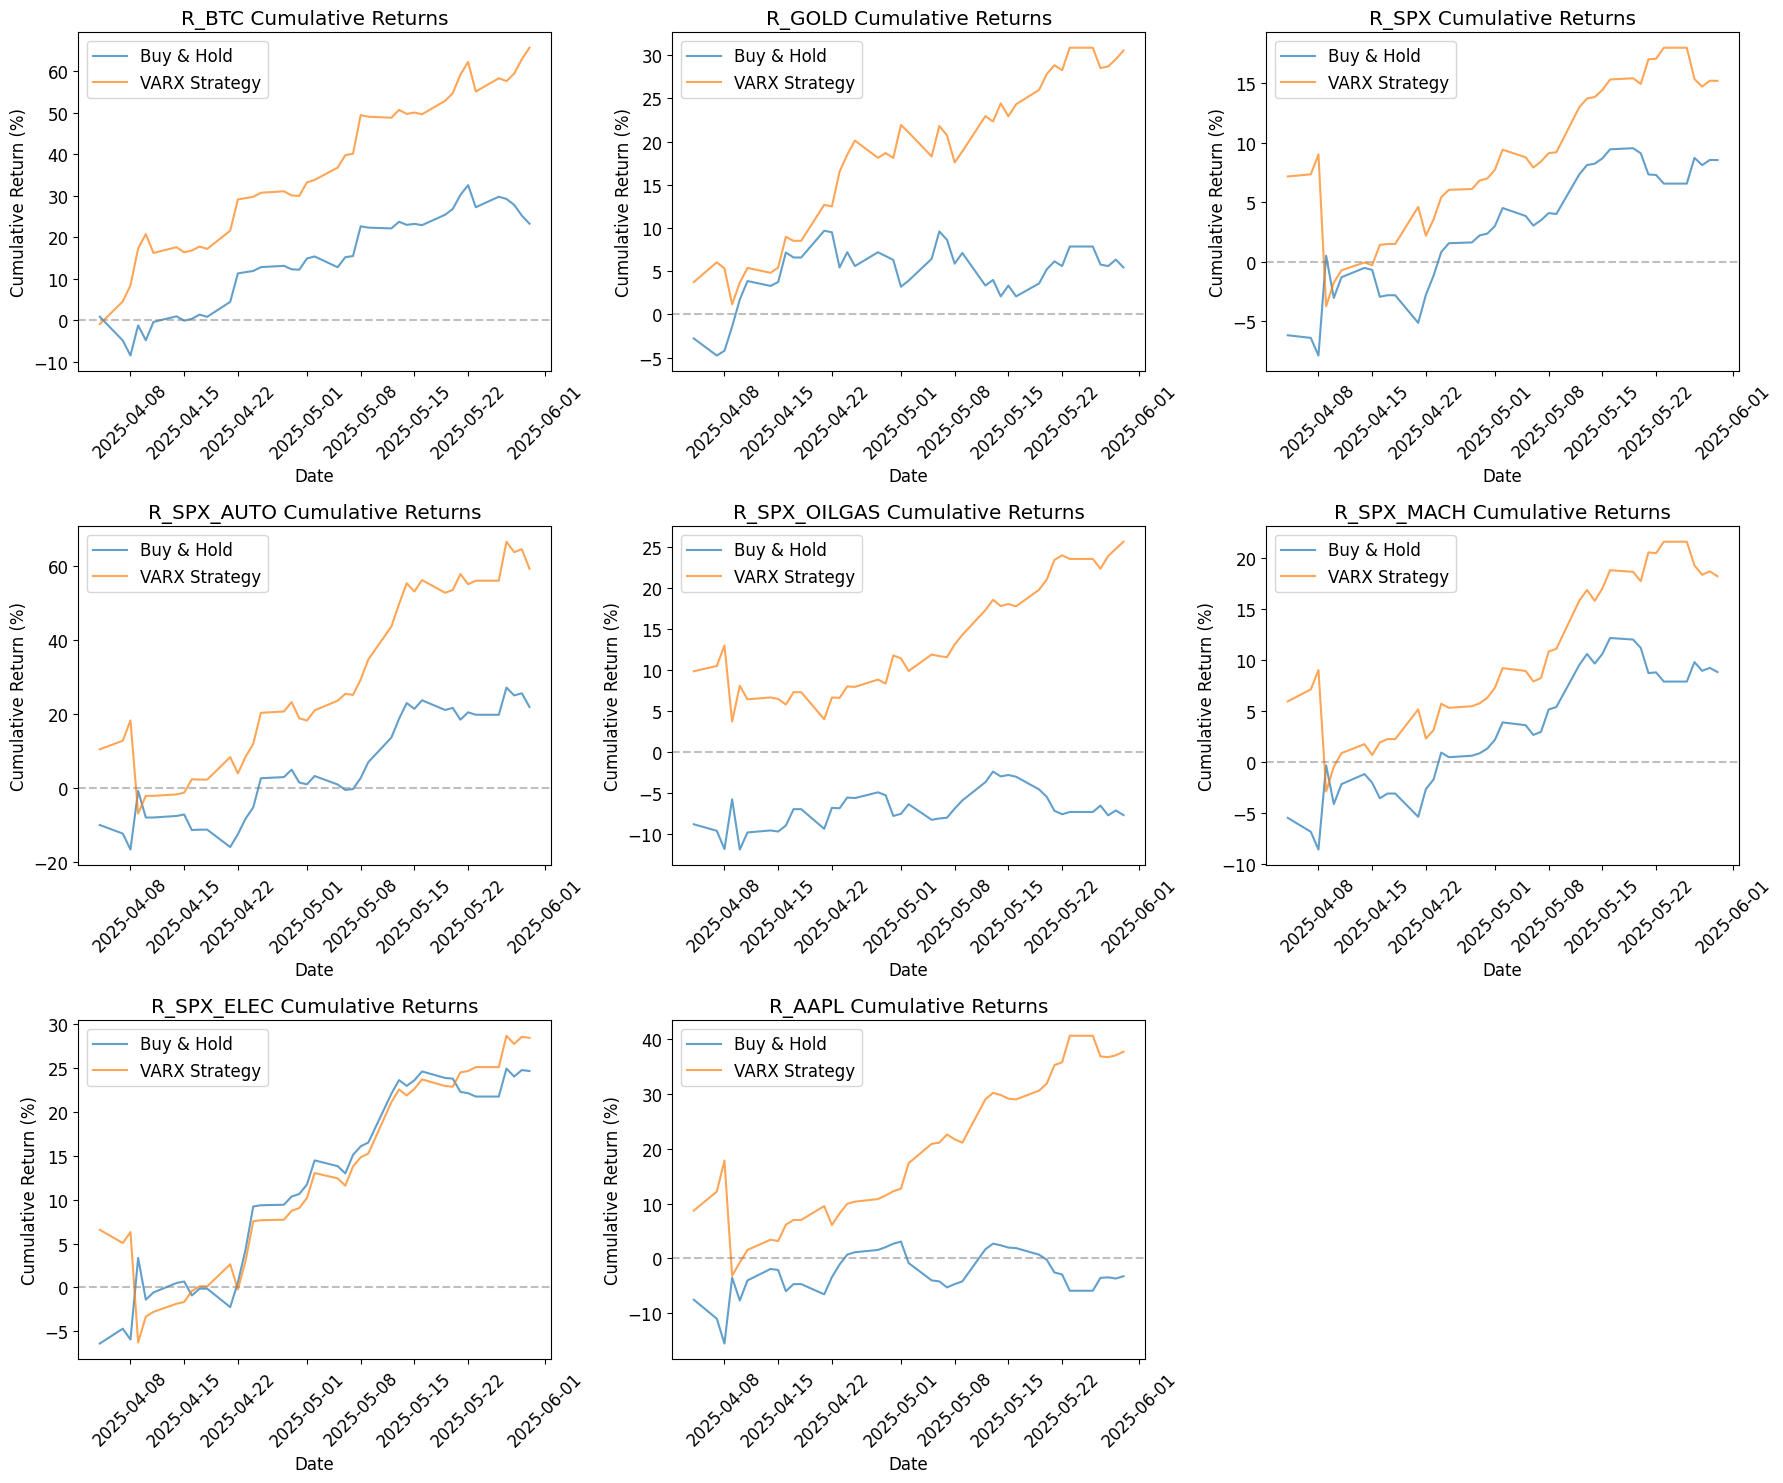


Cumulative Returns Summary:
  r_btc:
    Buy & Hold: 23.27%
    Strategy:   65.63%
  r_gold:
    Buy & Hold: 5.44%
    Strategy:   30.55%
  r_spx:
    Buy & Hold: 8.54%
    Strategy:   15.19%
  r_spx_auto:
    Buy & Hold: 21.97%
    Strategy:   59.37%
  r_spx_oilgas:
    Buy & Hold: -7.72%
    Strategy:   25.61%
  r_spx_mach:
    Buy & Hold: 8.78%
    Strategy:   18.18%
  r_spx_elec:
    Buy & Hold: 24.65%
    Strategy:   28.42%
  r_aapl:
    Buy & Hold: -3.27%
    Strategy:   37.76%

Trading Metrics Summary:

R_BTC:
  Sharpe Ratio:     8.229
  Sortino Ratio:    14.143
  Calmar Ratio:     72.858
  Max Drawdown:     -4.38%
  Win Rate:         70.7%
  Profit Factor:    4.95

R_GOLD:
  Sharpe Ratio:     5.726
  Sortino Ratio:    10.111
  Calmar Ratio:     36.761
  Max Drawdown:     -4.59%
  Win Rate:         58.5%
  Profit Factor:    2.50

R_SPX:
  Sharpe Ratio:     2.430
  Sortino Ratio:    1.616
  Calmar Ratio:     8.105
  Max Drawdown:     -11.69%
  Win Rate:         73.2%
  Profit Fa

In [22]:
# Compute momentum-based trading strategy with volatility scaling
from modules.finance.evaluation.trading_metrics import (
    generate_volatility_scaled_positions,
    compute_trading_metrics
)

cumulative_returns = {}
trading_metrics_all = {}

n_cols = min(3, len(TARGET_COLS))
n_rows = (len(TARGET_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

for idx, target in enumerate(TARGET_COLS):
    preds_df = oos_predictions[target]
    
    # Get asset name
    asset = target.replace('r_', '')
    
    # Get momentum signal (5-day primary) and convert to ±1
    momentum_col = f'momentum_5d_{asset}'
    if momentum_col not in df_clean.columns:
        print(f"Warning: {momentum_col} not found, using sign of predictions")
        momentum_signal = np.sign(preds_df['y_pred'].values)
    else:
        # Align momentum with prediction dates and convert to directional signal
        momentum_values = df_clean.loc[preds_df.index, momentum_col].values
        momentum_signal = np.sign(momentum_values)  # Convert to ±1
    
    # Get signed actual returns (MUST use signed column, not y_true which is absolute)
    signed_col = f'r_{asset}_signed'
    if signed_col in df_clean.columns:
        actual_signed_returns = df_clean.loc[preds_df.index, signed_col].values
    else:
        # Fallback: convert absolute returns to signed using momentum
        print(f"Warning: {signed_col} not found, reconstructing from absolute returns")
        actual_signed_returns = preds_df['y_true'].values * momentum_signal
    
    # Generate volatility-scaled positions
    # y_pred contains predicted volatility (absolute returns), use for inverse vol weighting
    predicted_volatility = preds_df['y_pred'].values
    positions = generate_volatility_scaled_positions(
        momentum_signals=momentum_signal,
        predicted_volatility=predicted_volatility,
        percentile_cap=95,
        percentile_floor=5
    )
    
    # Strategy returns (position * actual signed return)
    strategy_returns = positions * actual_signed_returns
    
    # Cumulative returns
    cum_buy_hold = np.cumprod(1 + actual_signed_returns) - 1
    cum_strategy = np.cumprod(1 + strategy_returns) - 1
    
    cumulative_returns[target] = {
        'dates': preds_df.index,
        'buy_hold': cum_buy_hold,
        'strategy': cum_strategy,
        'final_buy_hold': cum_buy_hold[-1],
        'final_strategy': cum_strategy[-1],
    }
    
    # Compute trading metrics
    trading_metrics = compute_trading_metrics(
        strategy_returns=strategy_returns,
        buy_hold_returns=actual_signed_returns
    )
    trading_metrics_all[target] = trading_metrics
    
    # Plot
    ax = axes[idx]
    ax.plot(preds_df.index, cum_buy_hold * 100, label='Buy & Hold', alpha=0.7)
    ax.plot(preds_df.index, cum_strategy * 100, label='VARX Strategy', alpha=0.7)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{target.upper()} Cumulative Returns')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return (%)')
    ax.legend(loc='best')
    ax.tick_params(axis='x', rotation=45)

# Hide extra subplots if any
for idx in range(len(TARGET_COLS), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'varx_index_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\nCumulative Returns Summary:")
for target, data in cumulative_returns.items():
    print(f"  {target}:")
    print(f"    Buy & Hold: {data['final_buy_hold']*100:.2f}%")
    print(f"    Strategy:   {data['final_strategy']*100:.2f}%")

print("\nTrading Metrics Summary:")
for target, metrics in trading_metrics_all.items():
    print(f"\n{target.upper()}:")
    print(f"  Sharpe Ratio:     {metrics['sharpe_ratio']:.3f}")
    print(f"  Sortino Ratio:    {metrics['sortino_ratio']:.3f}")
    print(f"  Calmar Ratio:     {metrics['calmar_ratio']:.3f}")
    print(f"  Max Drawdown:     {metrics['max_drawdown']*100:.2f}%")
    print(f"  Win Rate:         {metrics['win_rate']*100:.1f}%")
    print(f"  Profit Factor:    {metrics['profit_factor']:.2f}")

## Save Results

In [23]:
# Save metrics
metrics_output = []
for target in TARGET_COLS:
    oos = oos_metrics[target]
    cum_ret = cumulative_returns[target]
    
    metrics_output.append({
        'asset': target,
        'model': 'VARX_emotion',
        'p': best_spec.p,
        'q_controls': best_spec.q_controls,
        'q_ei': best_spec.q_ei,
        'q_epi': best_spec.q_epi,
        'q_epi_signed': best_spec.q_epi_signed,
        'q_ccd': best_spec.q_ccd,
        'q_intensity': best_spec.q_intensity,
        'q_surprise': best_spec.q_surprise,
        'q_split': best_spec.q_split,
        'f_ei': best_spec.f_ei,
        'f_epi': best_spec.f_epi,
        'f_epi_signed': best_spec.f_epi_signed,
        'f_ccd': best_spec.f_ccd,
        'f_intensity': best_spec.f_intensity,
        'f_surprise': best_spec.f_surprise,
        'f_split': best_spec.f_split,
        'cv_mae': varx_result['best_score_mae'],
        'cv_rmse': varx_result['best_score_rmse'],
        'oos_mae': oos['mae'],
        'oos_rmse': oos['rmse'],
        'oos_mape': oos['mape'],
        'cum_return_buy_hold': cum_ret['final_buy_hold'],
        'cum_return_strategy': cum_ret['final_strategy'],
    })

pd.DataFrame(metrics_output).to_csv(OUTPUT_DIR / 'varx_emotion_metrics.csv', index=False)
print(f"Saved metrics to {OUTPUT_DIR / 'varx_emotion_metrics.csv'}")

# Save predictions
for target in TARGET_COLS:
    oos_predictions[target].to_csv(OUTPUT_DIR / f'varx_emotion_predictions_{target}.csv')
print(f"Saved predictions")

# Save bootstrap results
bootstrap_output = []
for target in TARGET_COLS:
    df_boot = bootstrap_results[target].reset_index()
    df_boot['asset'] = target
    bootstrap_output.append(df_boot)

pd.concat(bootstrap_output).to_csv(OUTPUT_DIR / 'varx_emotion_bootstrap.csv', index=False)
print(f"Saved bootstrap results")

# Save SHAP
shap_output = []
for target in TARGET_COLS:
    for feat, val in shap_results[target]['mean_abs_shap'].items():
        shap_output.append({'asset': target, 'feature': feat, 'mean_abs_shap': val})

pd.DataFrame(shap_output).to_csv(OUTPUT_DIR / 'varx_emotion_shap.csv', index=False)
print(f"Saved SHAP results")

print("\n✅ All VARX emotion results saved!")

Saved metrics to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/varx_emotion_metrics.csv
Saved predictions
Saved bootstrap results
Saved SHAP results

✅ All VARX emotion results saved!
